<img src="./imagenes/logo_UTN.svg" align="right" width="200"/>

# **Teoría de Circuitos II**
## Trabajo Semanal 2

---
**Profesor:** Mariano Llamedo Soria \
**Ayudante de TPs:** David Moharos \
**Jefe de TPs:** César Fuoco

**Alumno:** Valentin Dorrego\
**Curso:** R4052\
**Ciclo lectivo:** 2026  

---

## Se pide lo siguiente:

1. **Establezca la función transferencia pasa bajos** $T_{LPF}(s)$ mediante aproximación de máxima planicidad, por caso, Butterworth, de orden 6.

2. **Obtenga respuesta de módulo, fase y diagrama de polos y ceros** de forma cualitativa.

3. **Implemente una red normalizada** que responda a $T_{LPF}(s)$ mediante secciones de segundo orden (SOS) separadas por buffers.  
   En orden creciente de Q (Q1 < Q2 < Q3):
   - SOS_1: Sallen-Key  
   - SOS_2: KHN  
   - SOS_3: MFB  

4. **Indique las normas de frecuencia** $\Omega_\omega$ **e impedancia** $\Omega_z$ adoptadas y los ajustes necesarios para obtener una ganancia de 10 dB en la banda de paso.

5. **Verifique los resultados** obtenidos analíticamente mediante simulaciones numéricas y/o simbólicas en Python y circuitales en LTSpice.

---

## Bonus:

- ⭐ **Se pide implementar una función transferencia Butterworth de orden 7.**  
  ¿Puede reutilizar las SOSs obtenidas anteriormente? ¿Bastaría con cascadear una sección de primer orden?

- ⭐ **Indique qué modificaciones debería realizar** y obtenga la red normalizada correspondiente.

- ⭐ **Verifique los resultados** mediante simulaciones en Python y LTSpice.

- 📦 **Presentación en Jupyter Notebook.**

---

## Resolucion:
**1)** Mediante aproximacion de maxima planicidad partimos de $|T(j\omega)|^2=\frac{1}{1+\xi^2\omega^{2n}}$, en donde particularmente para el caso Butterworth $\rightarrow \xi^2=1$ quedando $|T(j\omega)|^2=\frac{1}{1+\omega^{2n}}$ en donde podemos decir que 
$\left. |T(j\omega)|^2 \right|_{\omega=\frac{s}{j}}= \frac{1}{1+ \left(\frac{s}{j}\right)^{2n}}$.
Como la red normalizada es de orden 6, tenemos que $n=6$ entonces operando un poco nos queda $\left. |T(j\omega)_6|^2 \right|_{\omega=\frac{s}{j}}= \frac{1}{1+ \left(s\right)^{12}}$.

Sabemos de antemano que como el sistema es de orden 6 tendremos 3 polos de complejos conjugados en el semiplano izquierdo, por lo tanto partimos de $1+s^12=0 \rightarrow s^{12}=-1=e^{j\pi}$. Operando un poco algebraicamente llegamos a los siguientes angulos de desplazamiento:

$$
\begin{aligned}
\theta_1 = \frac{\pi}{12}, \theta_2 = \frac{\pi}{4}, \theta_3 = \frac{5\pi}{12}\\
\end{aligned}
$$


<div align="center">
  <img src="imagenes/2/DiagramaDePolos.png" width="300">
  <figcaption>Figura 1: Diagrama de polos de un filtro Butterworth de orden 6 (ω₀ = 1).</figcaption>
</div>

Por lo tanto nos quedarian 3 sistemas de segundo orden en cascada, y como ya es una expresion conocida tenemos que $|T(j\omega)_2| = \frac{1}{s^2+s\left(2\cos{\theta_k}\right)+1}$ por lo tanto el resultado final seria

$$
\boxed{
\begin{aligned}
\quad |T_6(s)| = \frac{1} { \left( s^2+ s\left( \frac{\sqrt{6}+\sqrt{2}}{2}\right) +1 \right) \left( s^2+\sqrt{2}+1\right) \left( s^2+ s\left( \frac{\sqrt{6}-\sqrt{2}}{2}\right) +1\right)}\\
\end{aligned}}
$$

$$
\boxed{
\begin{aligned}
Q_1=\frac{2}{\sqrt{6}+\sqrt{2}},
Q_2=\frac{1}{\sqrt{2}},
Q_3=\frac{2}{\sqrt{6}-\sqrt{2}}
\end{aligned}}
$$

**2)**
    **Respuesta de modulo:**
  $$
  \begin{aligned}
  |T(j\omega)|^2=\frac{1}{1+\omega^{2n}}
  \end{aligned}
  $$
A partir de esta ecuación observamos algunas propiedades interesantes de la respuesta de Butterworth:

1) El filtro Butterworth es un filtro de **solo polos** (*all-pole*); tiene ceros únicamente en el infinito ($\omega \to \infty$).
2) $|T_n(j0)| = 1$ para todo $n$. Esto es una consecuencia de la normalización.
3) $|T_n(j1)| = 1/\sqrt{2} \approx 0.707$ para todo $n$, lo cual corresponde a $-3$ dB.
4) Para valores grandes de $\omega$, $|T_n(j\omega)|$ exhibe una caída de $n$ polos (*n-pole roll-off*), es decir, la atenuación aumenta en $20n$ dB por década.

  <div align="center">
  <img src="imagenes/2/DiagramaDeModulo.png" width="500">
  <figcaption>Figura 2: Ilustra las magnitudes de los filtros Butterworth de órdenes 1 al 10.</figcaption>
</div>

**Respuesta de fase:**
    
A diferencia de la magnitud, la fase del filtro Butterworth no es perfectamente plana y presenta una rotación gradual. A partir del análisis de la función de transferencia, podemos observar las siguientes propiedades:

1) No linealidad: La respuesta de fase es inherentemente no lineal. Esta falta de linealidad aumenta con el orden $n$, lo que implica que el filtro introduce distorsión de retardo cerca de la frecuencia de corte.
2) Desplazamiento de fase total: El desplazamiento de fase total cuando la frecuencia varía de $0$ a $\infty$ está determinado por el número de polos $n$:
   $$\phi_{total} = -n \times 90^\circ$$
3) Fase en la frecuencia de corte: En la frecuencia de corte normalizada ($\omega = 1$), la fase siempre toma el valor de:
   $$\phi(j1) = -n \times 45^\circ$$
   Esto indica que cada polo del filtro contribuye exactamente con $-45^\circ$ en el punto de $-3$ dB.
4) Retraso de grupo (Group Delay): El retraso de grupo, definido como $-\frac{d\phi}{d\omega}$, no es constante. Presenta un incremento o "pico" en las proximidades de $\omega = 1$, lo que significa que las frecuencias cercanas al corte se retrasan más que las frecuencias bajas.
    
<div align="center">
<img src="imagenes/2/DiagramaDeFase.png" width="500">
<figcaption>Figura 3: Ilustra las fases de los filtros Butterworth de órdenes 1 al 10.</figcaption>
</div>

 **Distribución de Polos y ceros**

Para que la magnitud de la respuesta sea máximamente plana, los polos del filtro de Butterworth deben seguir una configuración geométrica específica en el plano complejo $s$:

1) Ubicación en el Círculo Unitario: Todos los polos se encuentran sobre un círculo de radio $\omega_c$ (frecuencia de corte) en el plano $s$. Para el caso normalizado, el radio es $1$.
2) Simetría en el Semi-plano Izquierdo: Para garantizar la estabilidad del filtro, solo se consideran los polos ubicados en el semi-plano izquierdo ($LHP$).
3) Separación Angular: Los $n$ polos están distribuidos uniformemente con una separación angular de:
   $$\Delta\theta = \frac{180^\circ}{n}$$
4) Ángulo de los Polos: La ubicación angular de cada polo $k$ respecto al eje real negativo se puede calcular mediante:
   $$\theta_k = \pm \frac{(2k - 1)90^\circ}{n}$$
   donde $k = 1, 2, \dots, n/2$ para $n$ par. Si $n$ es impar, siempre habrá un polo real ubicado exactamente en $s = -1$.
5) Efecto del Orden $n$: A medida que $n$ aumenta, los polos se "aprietan" más cerca del eje imaginario $j\omega$, lo que resulta en una transición más abrupta (una "rodilla" más afilada) entre la banda de paso y la de rechazo.

<div align="center">
  <img src="imagenes/2/DiagramaDePolos.png" width="300">
  <figcaption>Figura 4: Diagrama de polos de un filtro Butterworth de orden 6 (ω₀ = 1).</figcaption>
</div>

**3.**
<div align="center">
  <img src="imagenes/2/RedNormalizada.png" width="1200">
  <figcaption>Figura 5: red normalizada que responda a $T_{LPF}(s)$.</figcaption>
</div>

Hallamos las tranferencias de cada etapa:

**SOS_1: Sallen-Key**
<div align="center">
  <img src="imagenes/2/Sallen-Key.png" width="500">
  <figcaption>Figura 6: Topologia Sallen-Key $T_{SK}(s)$.</figcaption>
</div>

$$
\boxed{
T(s)_{SK} = \frac{V_o(s)}{V_i(s)} = \frac{\frac{G_1 G_2}{C_1 C_2} \left( 1 + \frac{G_3}{G_4} \right)}{s^2 + s \left( \frac{(G_1 + G_2) C_1 G_4 - C_2 G_2 G_3}{C_1 C_2 G_4} \right) + \frac{G_1 G_2}{C_1 C_2}}}
Nomalizada\rightarrow
\boxed{
T(s)_{SK} = \frac{V_o(s)}{V_i(s)} = \frac{3-\frac{1}{Q_1}}{s^2 + s \frac{1}{Q_1}+1} 
}
$$
    
**SOS_2: KHN**
<div align="center">
  <img src="imagenes/2/KHN.png" width="700">
  <figcaption>Figura 7: Topologia Kerwin-Huelsman-Newcomb $T_{KHN}(s)$.</figcaption>
</div>

$$
\boxed{
H(s)_{KHN} = \frac{V_L(s)}{V_i(s)} = -\frac{G_1 G_4 G_5}{C_1 C_2 G_3} \cdot \frac{1}{s^2 + s \frac{G_4 G_6}{C_1 G_3} \cdot \frac{(G_1 + G_2 + G_3)}{(G_6 + G_7)} + \frac{G_2 G_5}{C_1 C_2}}}
  Nomalizada\rightarrow
\boxed{
T(s)_{KHN} = \frac{V_o(s)}{V_i(s)} = -\frac{1}{s^2 + s \frac{1}{Q_2}+1} 
} 
$$


**SOS_3: MFB**
<div align="center">
  <img src="imagenes/2/MFB.png" width="450">
  <figcaption>Figura 8: Topologia Multiple Feedback $T_{MFB}(s)$.</figcaption>
</div>

$$\boxed{
T(s)_{MFB} = \frac{V_o(s)}{V_i(s)} = -\frac{G_2 G_3}{C_1 C_2} \cdot \frac{1}{s^2 + s \frac{G_1 + G_2 + G_3}{C_1} + \frac{G_1 G_2}{C_1 C_2}} 
}  Nomalizada\rightarrow
\boxed{
T(s)_{MFB} = \frac{V_o(s)}{V_i(s)} = -\frac{1}{s^2 + s \frac{1}{Q_3}+1} 
} 
$$

**4)**

**SOS_1: Sallen-Key**
$$
\begin{aligned}
G_1 &= G_2 = G_4 = 1 \\
C_1 &= C_2 = 1 \\
G_3 &= 2 - \frac{1}{Q_1} \\
\omega_0 &= 1
\end{aligned}
$$

**SOS_2: KHN**
$$
\begin{aligned}
G_1 &= G_2 = G_3 = G_4 = G_5 = G_6 = G_7 = 1 \\
C_1 &= \frac{3\cdot Q_2}{2} \\
C_2 &= \frac{2}{3\cdot Q_2} \\
\omega_0 &= 1
\end{aligned}
$$

**SOS_3: MFB**
$$
\begin{aligned}
G_1 &= G_2 = G_4 = 1 \\
C_1 &= 3\cdot Q_3\\
C_2 &= \frac{1}{3\cdot Q_3}\\
\omega_0 &= 1
\end{aligned}
$$

Para tener una ganancia de 10db en la banda de paso, deberiamos poner $Q_1$ = 10, por lo tanto la transferencia del Sallen-Key nos quedaria:
$$
\boxed{
H(s)_{KHN} = \frac{V_L(s)}{V_i(s)} = \frac{3-\frac{1}{10}}{s^2 + s \frac{1}{10}+ 1}
}\rightarrow
\boxed{
G_{db} = 20\cdot log(2.9)\approx10db
} 
$$
Como las etapas posteriores a esta tienen ganancias = 1, con este cambio seria suficiente.

**5)** Verificacion de resultados

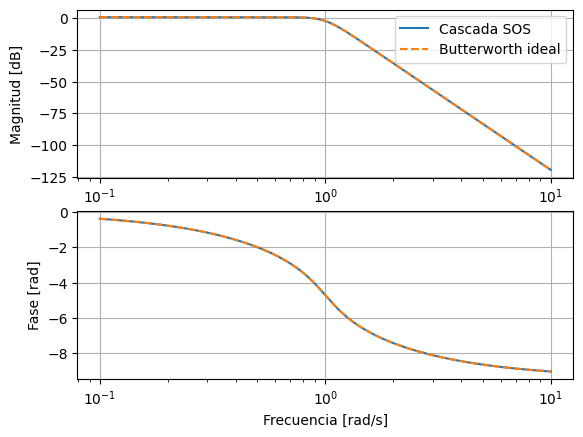

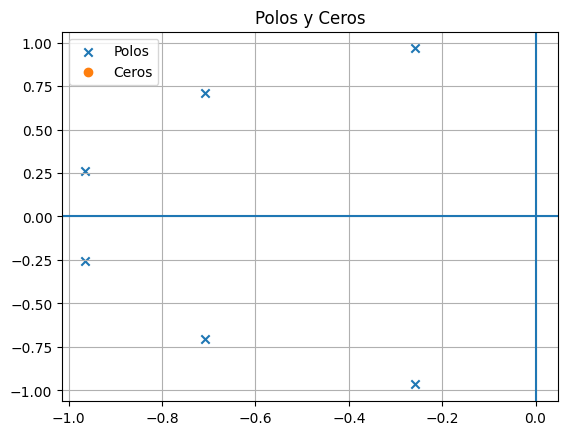

In [1]:
#%%
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# =========================
# Parámetros del problema
# =========================

# Qs dados
Q1 = 2/(np.sqrt(6)+np.sqrt(2))
Q2 = 1/np.sqrt(2)
Q3 = 2/(np.sqrt(6)-np.sqrt(2))
 
K_total = 3-1/Q1
# =========================
# Definición de cada SOS
# =========================

def sos_tf(Q, K=1, invert=True):
    """
    Devuelve numerador y denominador de una SOS:
    T(s) = ± K / (s^2 + s/Q + 1)
    """
    num = [K]
    den = [1, 1/Q, 1]
    
    if invert:
        num = [-K]
    
    return signal.TransferFunction(num, den)

# =========================
# Construcción de etapas
# =========================

# OJO: solo le metemos la ganancia total a una etapa
# (práctica real)
H1 = sos_tf(Q1, K=K_total,invert=False)   # Sallen-Key
H2 = sos_tf(Q2)              # KHN
H3 = sos_tf(Q3)              # MFB

# =========================
# Cascada total
# =========================

# multiplicación de transferencias
def cascade(tf_list):
    num = [1]
    den = [1]
    
    for tf in tf_list:
        num = np.polymul(num, tf.num)
        den = np.polymul(den, tf.den)
    
    return signal.TransferFunction(num, den)

H_total = cascade([H1, H2, H3])

# =========================
# Butterworth ideal orden 6
# =========================

b_butt, a_butt = signal.butter(6, 1, analog=True)
H_butt = signal.TransferFunction(b_butt * K_total, a_butt)

# =========================
# Bode
# =========================

w = np.logspace(-1, 1, 1000)

w, mag, phase = signal.bode(H_total, w)
_, mag_b, phase_b = signal.bode(H_butt, w)

plt.figure()
plt.subplot(2,1,1)
plt.semilogx(w, mag, label='Cascada SOS')
plt.semilogx(w, mag_b, '--', label='Butterworth ideal')
plt.ylabel('Magnitud [dB]')
plt.legend()
plt.grid()

plt.subplot(2,1,2)
plt.semilogx(w, phase*np.pi/180, label='Cascada SOS')
plt.semilogx(w, phase_b*np.pi/180, '--', label='Butterworth ideal')
plt.ylabel('Fase [rad]')
plt.xlabel('Frecuencia [rad/s]')
plt.grid()

# =========================
# Polos y ceros
# =========================

z, p, k = signal.tf2zpk(H_total.num, H_total.den)

plt.figure()
plt.scatter(np.real(p), np.imag(p), marker='x', label='Polos')
plt.scatter(np.real(z), np.imag(z), marker='o', label='Ceros')
plt.axhline(0)
plt.axvline(0)
plt.title('Polos y Ceros')
plt.legend()
plt.grid()

plt.show()

**Simulacion Spice**
<div align="center">
  <img src="imagenes/2/Circuito.png" width="1500">
  <figcaption>Figura 9: circuito completo $T_{6}(s)$.</figcaption>
</div>


<div align="center">
  <img src="imagenes/2/ModuloYFaseSpice.png" width="500">
  <figcaption>Figura 10: Respuesta de modulo y fase $T_{6}(s)$.</figcaption>
</div>

### **Conclusiones**

Se diseñó un filtro pasa bajos de orden 6 utilizando la aproximación de Butterworth filter, cuya principal característica es presentar una respuesta de magnitud completamente plana en la banda pasante y una caída monótona en la banda de rechazo. A partir de la factorización de la función transferencia total, se obtuvo una implementación en cascada mediante tres secciones de segundo orden (SOS), cada una caracterizada por un factor de calidad distinto. Los valores de Q obtenidos coinciden con los teóricos del Butterworth de orden 6, lo que asegura que la respuesta global del sistema preserve las propiedades de máxima planicidad.
El análisis de la función transferencia permitió determinar los polos del sistema, los cuales se ubican en el semiplano izquierdo del plano complejo y sobre una circunferencia de radio unitario. Esta distribución es consistente con la teoría del filtro Butterworth y garantiza estabilidad y comportamiento adecuado en frecuencia. Asimismo, la descomposición en secciones de segundo orden permitió implementar el filtro utilizando distintas topologías activas (Sallen-Key, KHN y MFB), ordenadas en función creciente del factor de calidad, lo cual resulta conveniente desde el punto de vista práctico para reducir la sensibilidad a tolerancias y mejorar la robustez del circuito.

---

## Anexo Calculos

[Ver PDF](https://github.com/ValentinDorrego/tc2/blob/main/jupyterNotebooks/Pdfs/TrabajoSemanal2Res.pdf)

In [2]:
from IPython.display import display, HTML

display(HTML("""
<div style="display: flex; justify-content: center;">
    <iframe src="./Pdfs/TrabajoSemanal2Res.pdf" width="900" height="900"></iframe>
</div>
"""))